### Extracción Visual y Muestreo por Fases

Este bloque de código conforma el motor de extracción visual que actúa como puente entre los vídeos ya preprocesados y la API del modelo multimodal. Su función principal es procesar estas secuencias para aislar exclusivamente la acción del lanzador, eliminando el ruido del fondo y preparando un paquete de imágenes optimizado que no sature la ventana de contexto de la red neuronal.

Para lograr esta focalización geométrica, el algoritmo sincroniza primero los índices del vídeo actual con los datos de las cajas delimitadoras (*bounding boxes*), calculando y compensando los desfases temporales generados durante la estandarización a 64 fotogramas. Una vez localizado al jugador, aplica un recorte con un margen de seguridad dinámico y escala la imagen a una resolución fija de 384x384 píxeles. Esta redimensión se realiza añadiendo franjas negras de relleno, una técnica indispensable para preservar intacta la relación de aspecto original y evitar cualquier deformación óptica que pudiera corromper la lectura biomecánica del modelo de visión.

Finalmente, el *script* orquesta el muestreo temporal de la secuencia utilizando el índice del impacto como ancla. A partir de esa referencia, fracciona el vídeo en las cuatro ventanas lógicas del gesto y extrae de forma equidistante un número estrictamente definido de fotogramas por fase (4, 6, 3 y 6 respectivamente). Estas imágenes definitivas son codificadas sobre la marcha al formato Base64, quedando preparadas para su inyección directa en las peticiones HTTP hacia el servidor de inferencia local.

In [2]:
import cv2
import base64
import os
import time
import pandas as pd
from openai import OpenAI
import matplotlib.pyplot as plt
import numpy as np

# CONFIGURACIÓN
# 8192
CLIENT = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")

BASE_DIR = r'C:\Users\david\OneDrive\Desktop\TFT_LLMPenalties2026'
CSV_ORIGINAL_PATH = os.path.join(BASE_DIR, 'labeled_frames_cuttedvids.csv')
CSV_GROUPED_PATH = os.path.join(BASE_DIR, 'labeled_frames_grouped.csv')
VIDEOS_DIR = os.path.join(BASE_DIR, 'modified_videos')
RESULTADOS_MEMORIA_PATH = os.path.join(BASE_DIR, 'memorias_visuales.csv')
DF_ORIGINAL = pd.read_csv(CSV_ORIGINAL_PATH)

def resize_keep_aspect_ratio(image, target_size=384):
    """ Escala una imagen sin deformarla y añade franjas negras """
    old_h, old_w = image.shape[:2]
    ratio = min(target_size / old_w, target_size / old_h)
    new_w = int(old_w * ratio)
    new_h = int(old_h * ratio)
    
    if ratio < 1.0:
        interp = cv2.INTER_AREA
    else:
        interp = cv2.INTER_CUBIC
        
    resized = cv2.resize(image, (new_w, new_h), interpolation=interp)
    
    delta_w = target_size - new_w
    delta_h = target_size - new_h
    top, bottom = delta_h // 2, delta_h - (delta_h // 2)
    left, right = delta_w // 2, delta_w - (delta_w // 2)
    
    padded_img = cv2.copyMakeBorder(resized, top, bottom, left, right, 
                                    cv2.BORDER_CONSTANT, value=[0, 0, 0])
    return padded_img

def encode_image_to_base64(frame):
    _, buffer = cv2.imencode('.jpg', frame, [int(cv2.IMWRITE_JPEG_QUALITY), 95])
    return base64.b64encode(buffer).decode('utf-8')

def get_correct_bbox(vid_data, frame_idx_modificado, target_frames=64):
    total_original_frames = len(vid_data)
    if total_original_frames == 0: return None
    if total_original_frames > target_frames:
        indice_real = frame_idx_modificado + (total_original_frames - target_frames)
    elif total_original_frames < target_frames:
        padding_size = target_frames - total_original_frames
        indice_real = 0 if frame_idx_modificado < padding_size else frame_idx_modificado - padding_size
    else:
        indice_real = frame_idx_modificado
    indice_real = min(indice_real, len(vid_data) - 1)
    return int(vid_data.iloc[indice_real]['BB_x']), int(vid_data.iloc[indice_real]['BB_y']), int(vid_data.iloc[indice_real]['BB_w']), int(vid_data.iloc[indice_real]['BB_h'])

def get_kick_frame_idx(vid_data, target_frames=64):
    total_orig = len(vid_data)
    kick_rows = vid_data[vid_data['kick_frame'] == 1]
    kick_orig = int(kick_rows.iloc[0]['frame_id']) if len(kick_rows) > 0 else total_orig // 2

    if total_orig > target_frames:
        kick_mod = kick_orig - (total_orig - target_frames)
    elif total_orig < target_frames:
        kick_mod = kick_orig + (target_frames - total_orig)
    else:
        kick_mod = kick_orig

    total_mod = min(total_orig, target_frames)
    return max(0, min(total_mod - 1, kick_mod))

def crop_frame(frame, vid_data, frame_idx, target_frames=64, pad=100):
    """ Recorta el jugador usando el Bounding Box y añade un margen de padding dinámico """
    bbox = get_correct_bbox(vid_data, frame_idx, target_frames=target_frames)
    if bbox:
        x, y, w, h = bbox
        H, W, _ = frame.shape
        x1, y1 = max(0, x - pad), max(0, y - pad)
        x2, y2 = min(W, x + w + pad), min(H, y + h + pad)
        return resize_keep_aspect_ratio(frame[y1:y2, x1:x2], target_size=384)
    return resize_keep_aspect_ratio(frame, target_size=512)

def sample_frames_from_range(frames, vid_data, start, end, n_samples):
    segment = list(range(start, end))
    if not segment: return []
    if len(segment) <= n_samples:
        indices = segment
    else:
        indices = [segment[int(i * len(segment) / n_samples)] for i in range(n_samples)]
    return [encode_image_to_base64(crop_frame(frames[i], vid_data, i)) for i in indices]

def extract_frames_by_phase(video_path, vid_data, n_carrera_1=4, n_carrera_2=6, n_impacto=3, n_seguimiento=6):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret: break
        frames.append(frame)
    cap.release()
    if not frames: return None

    kick_idx = get_kick_frame_idx(vid_data)
    total = len(frames)
    
    fase_carrera_1   = (0, max(1, kick_idx - 12))
    
    fase_carrera_2   = (max(1, kick_idx - 12), max(2, kick_idx - 1))
    
    fase_impacto     = (max(0, kick_idx - 1), min(total, kick_idx + 2))
    
    fase_seguimiento = (min(total, kick_idx + 2), total)

    return {
        "carrera_1":     sample_frames_from_range(frames, vid_data, *fase_carrera_1,   n_carrera_1),
        "carrera_2":     sample_frames_from_range(frames, vid_data, *fase_carrera_2,   n_carrera_2),
        "impacto":       sample_frames_from_range(frames, vid_data, *fase_impacto,     n_impacto),
        "seguimiento":   sample_frames_from_range(frames, vid_data, *fase_seguimiento, n_seguimiento),
        "kick_idx":      kick_idx,
        "total":         total,
        "n_carrera_1":   n_carrera_1,
        "n_carrera_2":   n_carrera_2,
        "n_impacto":     n_impacto,
        "n_seguimiento": n_seguimiento,
    }

### Ilustración y Ajuste del Padding

Esta celda tiene una función puramente práctica: ilustrar el efecto del *padding* (margen) alrededor del jugador para ayudar a elegir el valor más adecuado antes de procesar todo el *dataset*.

El código toma un vídeo de prueba, localiza el fotograma exacto del golpeo y aplica la función de recorte probando una lista de diferentes márgenes (desde 10 hasta 150 píxeles). A continuación, utiliza Matplotlib para generar una figura con una cuadrícula de 8 subgráficos que muestra el resultado de cada recorte lado a lado.

Esta visualización sirve para comprobar de forma directa qué valor de *padding* funciona mejor. El objetivo es encontrar un margen intermedio: lo suficientemente grande para asegurar que no se queden fuera los brazos o las piernas del lanzador debido a la amplitud del movimiento, pero lo bastante ajustado para que el jugador siga ocupando la mayor parte de la imagen una vez que el fotograma se redimensione a 384x384 píxeles para el modelo.


 LABORATORIO DE PADDING: BUSCANDO EL PUNTO DULCE
[INFO] Generando visualizaciones de padding...


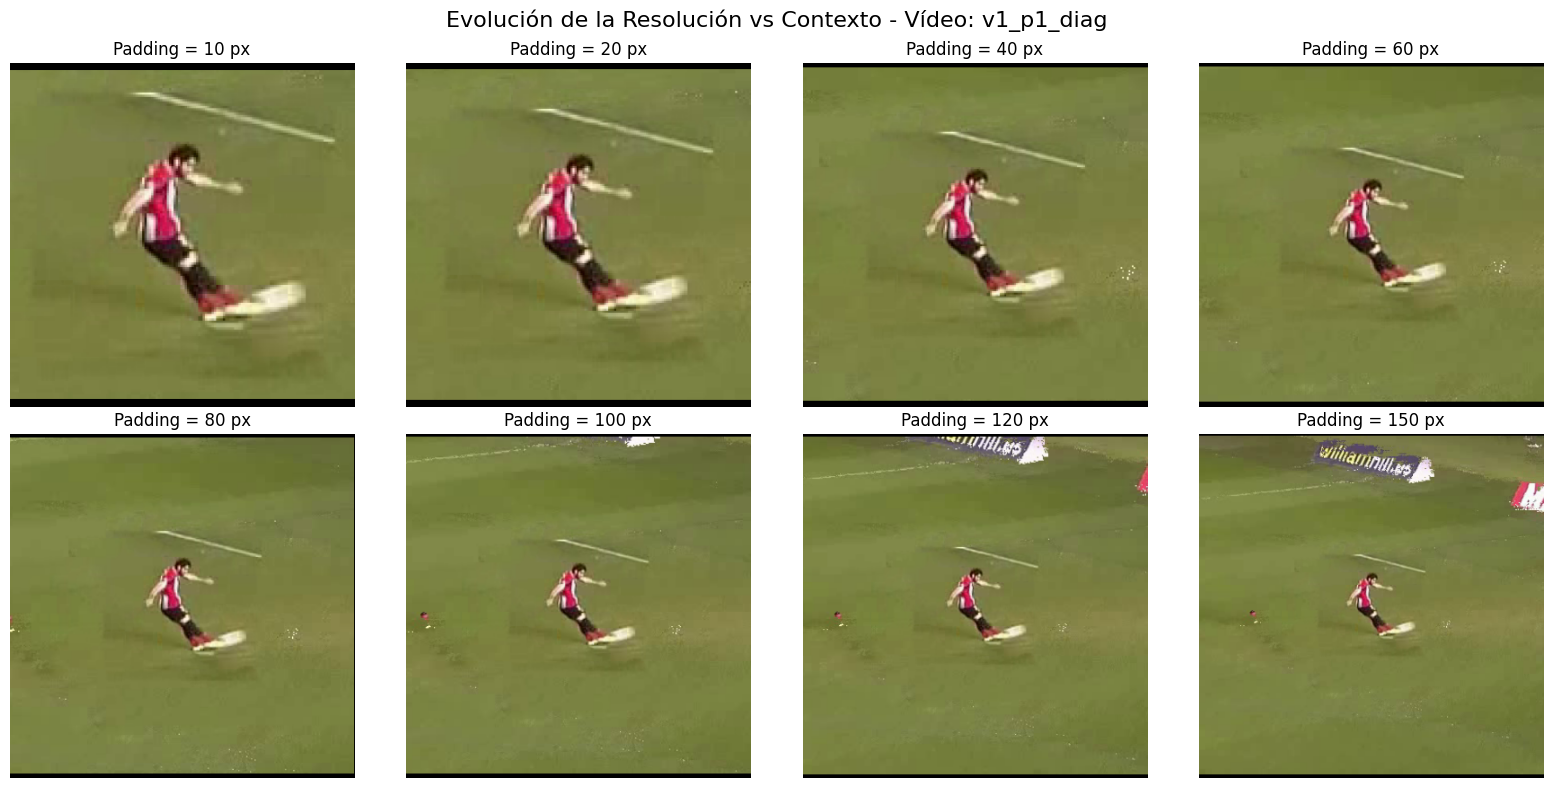

In [ ]:
import matplotlib.pyplot as plt

BASE_DIR = r'C:\Users\david\OneDrive\Desktop\TFT_LLMPenalties2026'
CSV_ORIGINAL_PATH = os.path.join(BASE_DIR, 'labeled_frames_cuttedvids.csv')
CSV_GROUPED_PATH = os.path.join(BASE_DIR, 'labeled_frames_grouped.csv')
VIDEOS_DIR = os.path.join(BASE_DIR, 'modified_videos')
RESULTADOS_MEMORIA_PATH = os.path.join(BASE_DIR, 'memorias_visuales.csv')
DF_ORIGINAL = pd.read_csv(CSV_ORIGINAL_PATH)

if __name__ == "__main__":
    print("\n" + "="*50)
    print(" LABORATORIO DE PADDING: BUSCANDO EL PUNTO DULCE")
    print("="*50)

    vid_id_test = DF_ORIGINAL['vid_ID'].iloc[0]
    video_path_test = os.path.join(VIDEOS_DIR, f"{vid_id_test}.mp4")
    vid_data_test = DF_ORIGINAL[DF_ORIGINAL['vid_ID'] == vid_id_test].sort_values(by='frame_id').reset_index(drop=True)
    
    if os.path.exists(video_path_test):
        kick_idx = get_kick_frame_idx(vid_data_test)
        
        cap = cv2.VideoCapture(video_path_test)
        cap.set(cv2.CAP_PROP_POS_FRAMES, kick_idx)
        ret, frame_original = cap.read()
        cap.release()

        if ret:
            pad_values = [10, 20, 40, 60, 80, 100, 120, 150]
            
            fig, axes = plt.subplots(2, 4, figsize=(16, 8))
            axes = axes.flatten()
            
            print("[INFO] Generando visualizaciones de padding...")
            
            for i, p in enumerate(pad_values):
                frame_test = crop_frame(frame_original, vid_data_test, kick_idx, pad=p)
                
                axes[i].imshow(cv2.cvtColor(frame_test, cv2.COLOR_BGR2RGB))
                axes[i].set_title(f"Padding = {p} px")
                axes[i].axis('off')
                
            plt.suptitle(f"Evolución de la Resolución vs Contexto - Vídeo: {vid_id_test}", fontsize=16)
            plt.tight_layout()
            plt.show()
            
        else:
            print("[ERROR] No se pudo leer el frame.")
    else:
        print("[ERROR] Vídeo no encontrado.")

### Preservación Geométrica y Evitación de Deformidad Anatómica

Esta celda funciona como una demostración visual y empírica para justificar el uso de la función `resize_keep_aspect_ratio` frente al redimensionamiento estándar de OpenCV (`cv2.resize`). Su objetivo es evidenciar cómo un procesamiento de imagen inadecuado puede destruir por completo la validez de un análisis biomecánico antes incluso de que la red neuronal procese la información.


Los modelos multimodales y las redes convolucionales exigen tensores de entrada con dimensiones cuadradas estrictas (en este caso, 384x384 píxeles). Sin embargo, los recortes extraídos mediante las cajas delimitadoras (*bounding boxes*) de los jugadores suelen ser rectangulares. Si se aplica un reescalado directo para forzar este rectángulo dentro de un cuadrado, la imagen sufre un aplastamiento o estiramiento asimétrico. Esta deformación óptica es crítica en el contexto deportivo: altera falsamente los ángulos de flexión de las rodillas, modifica la inclinación aparente del eje del torso y corrompe la dirección geométrica del impacto.

Para ilustrar esta problemática, el código extrae una secuencia completa del gesto (inicio, aproximación, impacto y seguimiento) y genera una gráfica comparativa. En la columna izquierda, muestra el resultado del redimensionamiento forzado, donde el jugador aparece artificialmente achatado. En la columna derecha, aplica la técnica de preservación de *ratio*: el encuadre original se escala simétricamente hasta alcanzar el límite máximo de resolución y los espacios vacíos se rellenan con franjas negras (*padding* constante). Esta segunda técnica asegura que el modelo multimodal analice una representación anatómica fiel a la realidad, garantizando que el razonamiento sobre la cadena cinética no se vea sesgado por artefactos de compresión.


 GENERANDO FIGURA: DEFORMACIÓN VS RATIO (SECUENCIA COMPLETA)
 Analizando el vídeo manual: v1_p2_diag
[EXITO] Imagen guardada como 'deformacion_secuencia_v1_p2_diag.png'


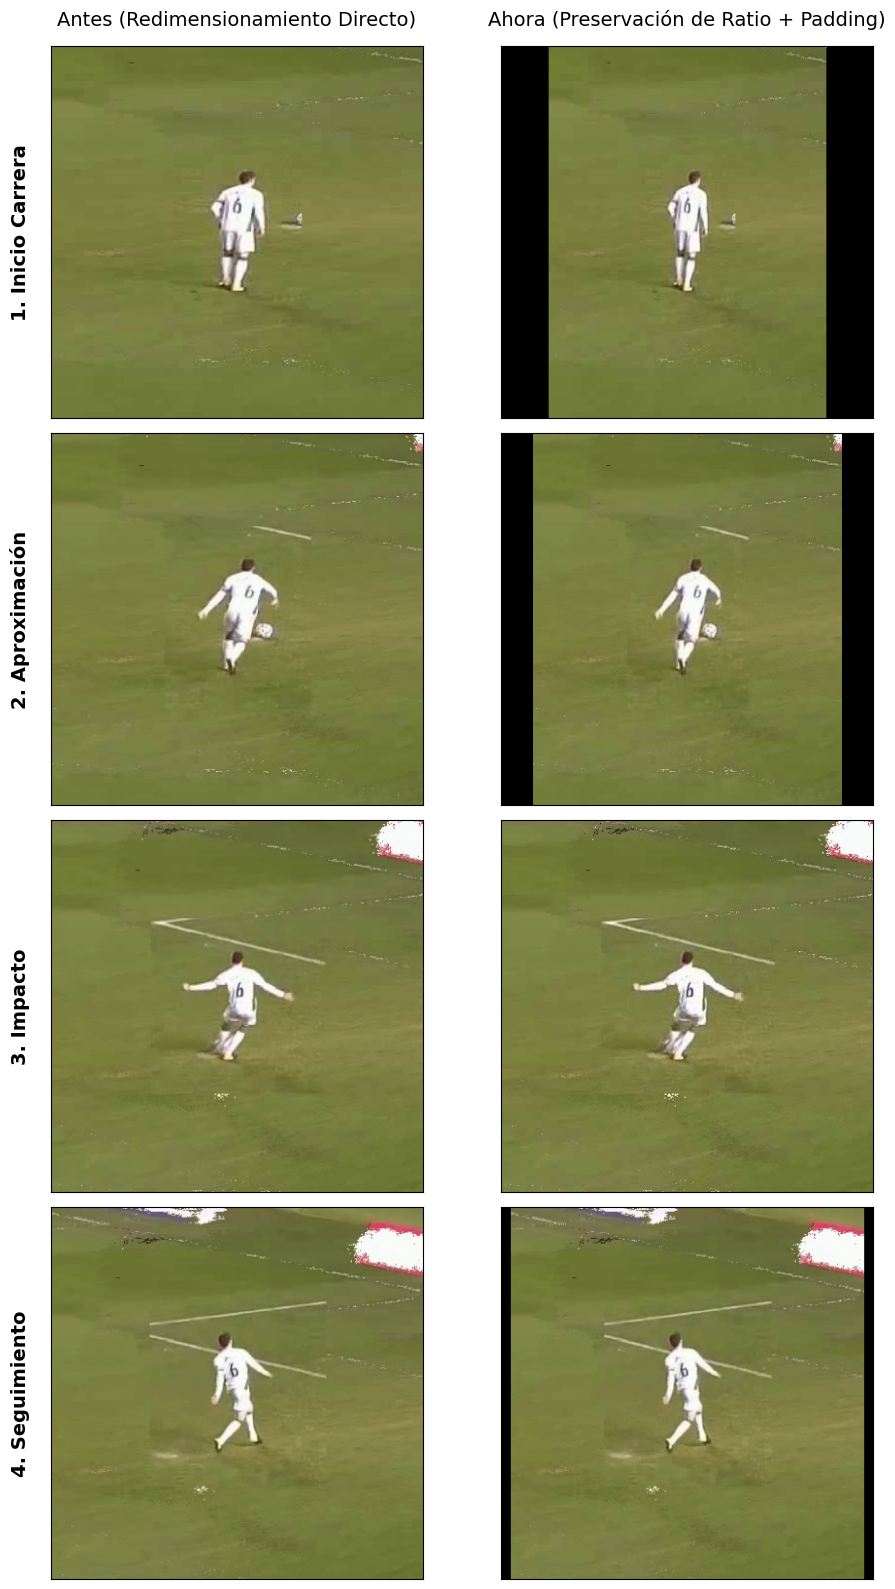

In [3]:
import cv2
import matplotlib.pyplot as plt
import os

def generar_figura_deformacion_secuencia(vid_id_test):
    print("\n" + "="*50)
    print(f" GENERANDO FIGURA: DEFORMACIÓN VS RATIO (SECUENCIA COMPLETA)")
    print(f" Analizando el vídeo manual: {vid_id_test}")
    print("="*50)

    video_path_test = os.path.join(VIDEOS_DIR, f"{vid_id_test}.mp4")
    vid_data_test = DF_ORIGINAL[DF_ORIGINAL['vid_ID'] == vid_id_test].sort_values(by='frame_id').reset_index(drop=True)
    
    if vid_data_test.empty or not os.path.exists(video_path_test):
        print(f"[ERROR] No se encontraron datos o el vídeo '{vid_id_test}' no existe.")
        return

    kick_idx = get_kick_frame_idx(vid_data_test)
    
    cap = cv2.VideoCapture(video_path_test)
    total_video_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_video_frames == 0:
        total_video_frames = 64 
    
    frames_to_plot = [
        0,
        max(0, kick_idx - 15),
        kick_idx,
        min(total_video_frames - 1, kick_idx + 10)
    ]
    
    titulos_filas = ["1. Inicio Carrera", "2. Aproximación", "3. Impacto", "4. Seguimiento"]

    fig, axs = plt.subplots(4, 2, figsize=(10, 16))

    for i, f_idx in enumerate(frames_to_plot):
        cap.set(cv2.CAP_PROP_POS_FRAMES, f_idx)
        ret, frame_original = cap.read()

        if not ret:
            print(f"[WARNING] No se pudo leer el frame {f_idx}")
            continue

        bbox = get_correct_bbox(vid_data_test, f_idx)
        if not bbox:
            continue

        x, y, w, h = bbox
        pad = 100
        H, W, _ = frame_original.shape
        x1, y1 = max(0, x - pad), max(0, y - pad)
        x2, y2 = min(W, x + w + pad), min(H, y + h + pad)
        
        recorte_puro = frame_original[y1:y2, x1:x2]

        imagen_deformada = cv2.resize(recorte_puro, (384, 384), interpolation=cv2.INTER_AREA)
        imagen_correcta = resize_keep_aspect_ratio(recorte_puro, target_size=384)

        axs[i, 0].imshow(cv2.cvtColor(imagen_deformada, cv2.COLOR_BGR2RGB))
        axs[i, 0].set_ylabel(titulos_filas[i], fontsize=14, fontweight='bold', labelpad=15)
        axs[i, 0].set_xticks([])
        axs[i, 0].set_yticks([])

        axs[i, 1].imshow(cv2.cvtColor(imagen_correcta, cv2.COLOR_BGR2RGB))
        axs[i, 1].set_xticks([])
        axs[i, 1].set_yticks([])

        if i == 0:
            axs[i, 0].set_title("Antes (Redimensionamiento Directo)", fontsize=14, pad=15)
            axs[i, 1].set_title("Ahora (Preservación de Ratio + Padding)", fontsize=14, pad=15)

    cap.release()
    plt.tight_layout()
    
    output_path = f"deformacion_secuencia_{vid_id_test}.png"
    plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"[EXITO] Imagen guardada como '{output_path}'")
    
    plt.show()

if __name__ == "__main__":
    VIDEO_ELEGIDO = "v1_p2_diag" 
    generar_figura_deformacion_secuencia(VIDEO_ELEGIDO)

### Auditoría Visual y Verificación de las Fases Biomecánicas

Esta última celda del cuaderno cumple una función de control de calidad estricto. Tras haber diseñado el complejo motor de recorte, redimensionamiento y segmentación temporal en la celda anterior, este *script* actúa como un entorno de depuración visual (*debug*) para verificar empíricamente que el empaquetado de las imágenes se ha realizado con éxito antes de enviarlas al Modelo de Visión-Lenguaje.

El mecanismo de comprobación realiza el camino de procesamiento inverso. A través de la función `decode_b64_image`, el código toma las cadenas de texto comprimidas en formato Base64 —que constituyen exactamente la carga útil (*payload*) que ingerirá la API del VLM— y las decodifica de vuelta a matrices de píxeles RGB interpretables por el ojo humano. A continuación, aísla un vídeo de prueba e invoca al motor de extracción para generar el diccionario de la secuencia.

Finalmente, el algoritmo utiliza Matplotlib para desplegar una representación gráfica secuencial estructurada por las cuatro ventanas biomecánicas: *Carrera 1*, *Carrera 2*, *Impacto* y *Seguimiento*. Esta visualización permite auditar de un solo vistazo que el muestreo temporal es correcto, que el instante del golpeo está perfectamente centrado en su fase correspondiente, y que la técnica de preservación de *ratio* ha mantenido la integridad geométrica del jugador a lo largo de toda la acción. En el contexto de la memoria del TFG, esta celda proporciona la evidencia metodológica y gráfica necesaria para certificar la robustez del *pipeline* visual antes de iniciar los procesos de inferencia masiva.

=== DEBUG VISUAL: VÍDEO v1_p4_diag ===
Frame de impacto detectado en el índice: 54 / 64 frames totales



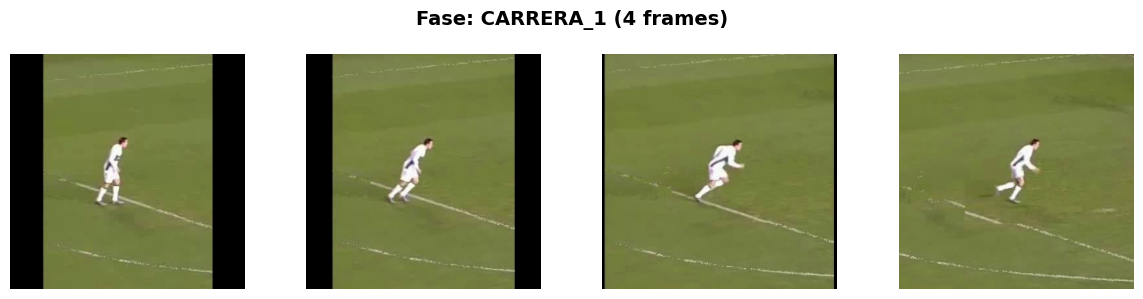

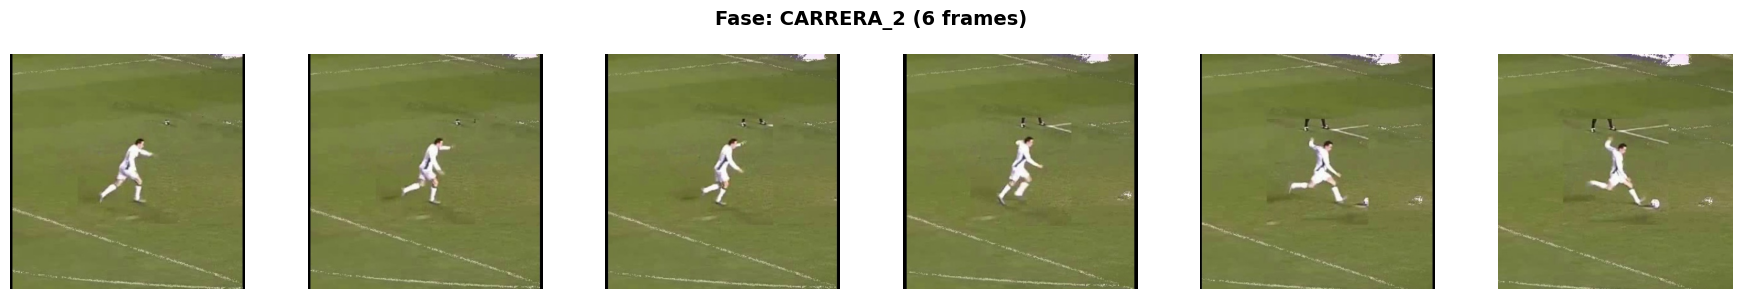

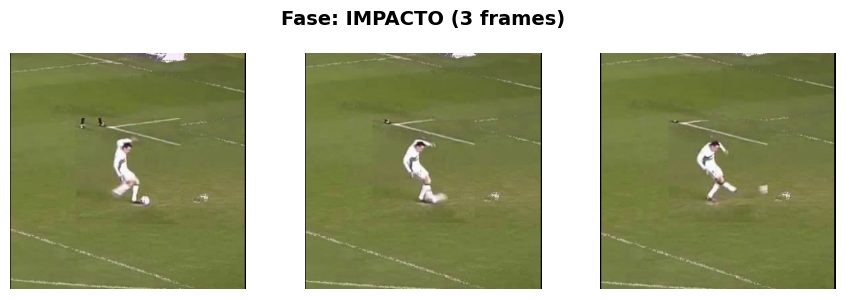

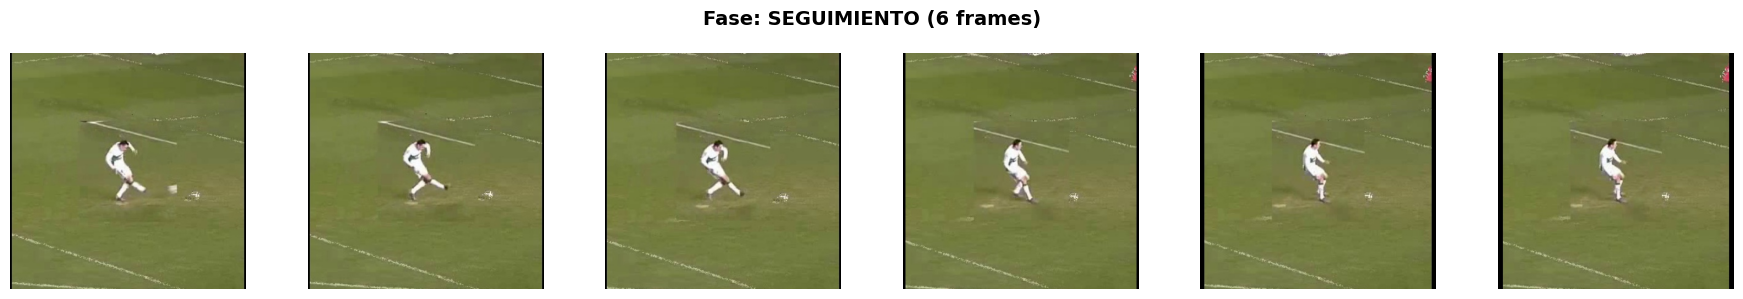

In [ ]:
import cv2
import numpy as np
import base64
import matplotlib.pyplot as plt
import os

def decode_b64_image(b64_string):
    img_data = base64.b64decode(b64_string)
    np_arr = np.frombuffer(img_data, np.uint8)
    img = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

vid_id_test = 'v1_p4_diag'
video_path = os.path.join(VIDEOS_DIR, f"{vid_id_test}.mp4")
vid_data_test = DF_ORIGINAL[DF_ORIGINAL['vid_ID'] == vid_id_test].sort_values(by='frame_id').reset_index(drop=True)

fases = extract_frames_by_phase(video_path, vid_data_test)

if fases:
    print(f"=== DEBUG VISUAL: VÍDEO {vid_id_test} ===")
    print(f"Frame de impacto detectado en el índice: {fases['kick_idx']} / {fases['total']} frames totales\n")
    
    fases_nombres = ["carrera_1", "carrera_2", "impacto", "seguimiento"]
    
    for fase in fases_nombres:
        frames_b64 = fases[fase]
        n_frames = len(frames_b64)
        
        if n_frames == 0:
            print(f"Fase {fase} vacía.")
            continue
            
        fig, axes = plt.subplots(1, n_frames, figsize=(3 * n_frames, 3))
        fig.suptitle(f"Fase: {fase.upper()} ({n_frames} frames)", fontsize=14, fontweight='bold')
        
        if n_frames == 1:
            axes = [axes]
            
        for ax, b64_str in zip(axes, frames_b64):
            img = decode_b64_image(b64_str)
            ax.imshow(img)
            ax.axis('off')
            
        plt.tight_layout()
        plt.show()
else:
    print("Error: No se pudieron extraer las fases del vídeo.")